In [2]:
%pip install pandas numpy matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd

recipes = pd.read_csv("../data/13k-recipes.csv")
calories = pd.read_csv("../data/calories.csv")
ingredients = pd.read_csv("../data/Detail ingredient.csv")
nutrition_1 = pd.read_csv("../data/Food Nutri.csv")
nutrition_2 = pd.read_csv("../data/Food Nutri 2.csv")
diet_recommendations = pd.read_csv("../data/Personalized_Diet_Recommendations.csv")

In [4]:
# recipes.head()
# calories.head()
# ingredients.head()
# nutrition_1.head()
# nutrition_2.head()
# diet_recommendations.head()

## Exploratory Data Analysis (EDA)

เป้าหมายของ EDA ชุดนี้:
- ตรวจสอบโครงสร้างและคุณภาพข้อมูล
- สำรวจการกระจายตัวและความสัมพันธ์ของตัวแปร
- สรุปประเด็นที่ต้องจัดการก่อนขั้นตอน modeling

In [5]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)

# Optional: seaborn for better plots
try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except ImportError:
    sns = None

DATASETS = {
    "recipes": recipes,
    "calories": calories,
    "ingredients": ingredients,
    "nutrition_1": nutrition_1,
    "nutrition_2": nutrition_2,
    "diet_recommendations": diet_recommendations,
}

print(f"Loaded {len(DATASETS)} datasets")

Loaded 6 datasets


In [6]:
# 1) Data overview (rows, columns, memory, column type counts)
overview_rows = []
for name, df in DATASETS.items():
    dtype_counts = df.dtypes.astype(str).value_counts().to_dict()
    overview_rows.append(
        {
            "dataset": name,
            "rows": df.shape[0],
            "columns": df.shape[1],
            "memory_mb": round(df.memory_usage(deep=True).sum() / (1024 ** 2), 2),
            "dtype_counts": dtype_counts,
        }
    )

overview = pd.DataFrame(overview_rows).sort_values(by=["rows", "columns"], ascending=False)
overview

,dataset,rows,columns,memory_mb,dtype_counts
3,nutrition_1,40000,24,33.12,"{'float64': 13, 'str': 9, 'int64': 2}"
0,recipes,13501,6,33.13,"{'str': 5, 'int64': 1}"
2,ingredients,8789,77,34.27,"{'str': 74, 'int64': 3}"
4,nutrition_2,7806,8,2.50,"{'str': 5, 'float64': 3}"
5,diet_recommendations,5000,30,3.47,"{'int64': 17, 'str': 11, 'float64': 2}"
1,calories,2225,5,0.61,{'str': 5}


In [7]:
# 2) Data quality check (missing values, duplicates, uniqueness)
def data_quality_report(df: pd.DataFrame, name: str) -> pd.DataFrame:
    total_rows = len(df)
    null_count = df.isna().sum()
    null_pct = (
        (null_count / total_rows * 100).round(2)
        if total_rows
        else pd.Series(0.0, index=df.columns)
    )
    nunique = df.nunique(dropna=True)

    report = pd.DataFrame(
        {
            "dataset": name,
            "column": df.columns,
            "dtype": df.dtypes.astype(str).values,
            "missing_count": null_count.values,
            "missing_pct": null_pct.values,
            "nunique": nunique.values,
        }
    )
    return report.sort_values("missing_pct", ascending=False)

quality_reports = {name: data_quality_report(df, name) for name, df in DATASETS.items()}

for name, report in quality_reports.items():
    dup_count = DATASETS[name].duplicated().sum()
    print(f"\n{name} | duplicates: {dup_count}")
    display(report.head(10))


recipes | duplicates: 0


,dataset,column,dtype,missing_count,missing_pct,nunique
3,recipes,Instructions,str,8,0.06,13464
1,recipes,Title,str,5,0.04,13305
0,recipes,Unnamed: 0,int64,0,0.00,13501
2,recipes,Ingredients,str,0,0.00,13473
4,recipes,Image_Name,str,0,0.00,13472
5,recipes,Cleaned_Ingredients,str,0,0.00,13473



calories | duplicates: 1


,dataset,column,dtype,missing_count,missing_pct,nunique
0,calories,FoodCategory,str,0,0.0,44
1,calories,FoodItem,str,0,0.0,1993
2,calories,per100grams,str,0,0.0,2
3,calories,Cals_per100grams,str,0,0.0,524
4,calories,KJ_per100grams,str,0,0.0,524



ingredients | duplicates: 0


...

,dataset,column,dtype,missing_count,missing_pct,nunique
16,nutrition_1,vitamin_c_mg,float64,17060,42.65,824
5,nutrition_1,brand_name,str,9746,24.36,7170
9,nutrition_1,household_serving,str,9210,23.02,4221
4,nutrition_1,brand_owner,str,8617,21.54,5552
6,nutrition_1,ingredients,str,8344,20.86,24684
7,nutrition_1,serving_size,float64,8158,20.40,635
8,nutrition_1,serving_unit,str,8158,20.40,8
17,nutrition_1,fiber_g,float64,6275,15.69,520
21,nutrition_1,cholesterol_mg,float64,5842,14.60,558
12,nutrition_1,calcium_mg,float64,5785,14.46,1034



nutrition_2 | duplicates: 5


,dataset,column,dtype,missing_count,missing_pct,nunique
0,nutrition_2,Diet_type,str,0,0.0,5
1,nutrition_2,Recipe_name,str,0,0.0,7062
2,nutrition_2,Cuisine_type,str,0,0.0,19
3,nutrition_2,Protein(g),float64,0,0.0,6060
4,nutrition_2,Carbs(g),float64,0,0.0,6618
5,nutrition_2,Fat(g),float64,0,0.0,6322
6,nutrition_2,Extraction_day,str,0,0.0,1
7,nutrition_2,Extraction_time,str,0,0.0,496



diet_recommendations | duplicates: 0


,dataset,column,dtype,missing_count,missing_pct,nunique
12,diet_recommendations,Allergies,str,3497,69.94,3
6,diet_recommendations,Chronic_Disease,str,2043,40.86,4
24,diet_recommendations,Food_Aversions,str,1225,24.50,3
0,diet_recommendations,Patient_ID,str,0,0.00,5000
16,diet_recommendations,Alcohol_Consumption,str,0,0.00,2
28,diet_recommendations,Recommended_Fats,int64,0,0.00,159
27,diet_recommendations,Recommended_Carbs,int64,0,0.00,388
26,diet_recommendations,Recommended_Protein,int64,0,0.00,177
25,diet_recommendations,Recommended_Calories,int64,0,0.00,2162
23,diet_recommendations,Preferred_Cuisine,str,0,0.00,4


## 3) Core EDA (All Datasets)

ส่วนนี้เป็น EDA แบบมาตรฐานที่ไม่ลึกเกินไป:
- Distribution: histogram ของคอลัมน์ตัวเลขที่สำคัญ
- Correlation: heatmap เฉพาะคอลัมน์ตัวเลข
- Outlier: boxplot + IQR summary

เพื่อให้ดูง่ายและรันเร็ว จะจำกัดจำนวนคอลัมน์ที่ plot ต่อ dataset

EDA: recipes
No numeric columns for EDA in this dataset.
EDA: calories
No numeric columns for EDA in this dataset.
EDA: ingredients
Numeric columns used: 1


,count,mean,std,min,25%,50%,75%,max
calories,8789.0,226.283878,169.862001,0.0,91.0,191.0,337.0,902.0


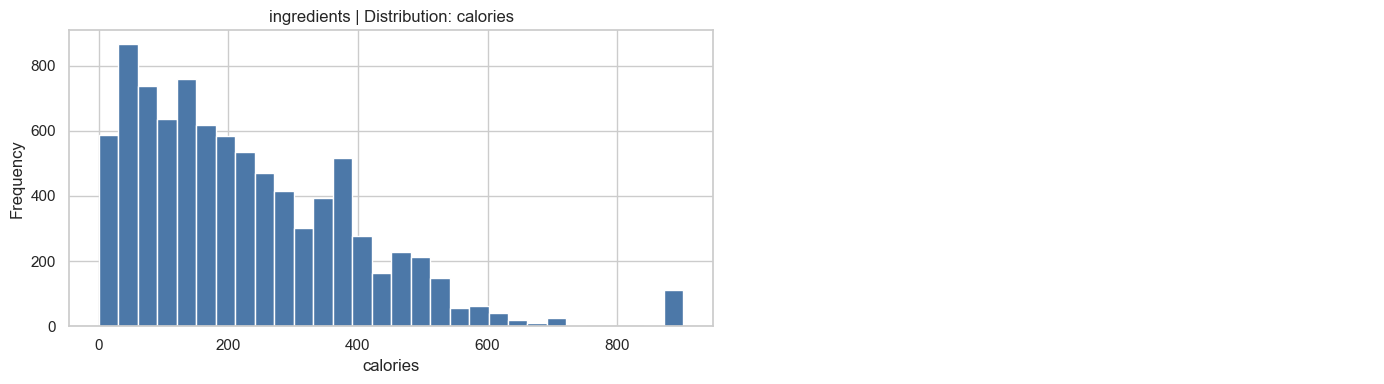

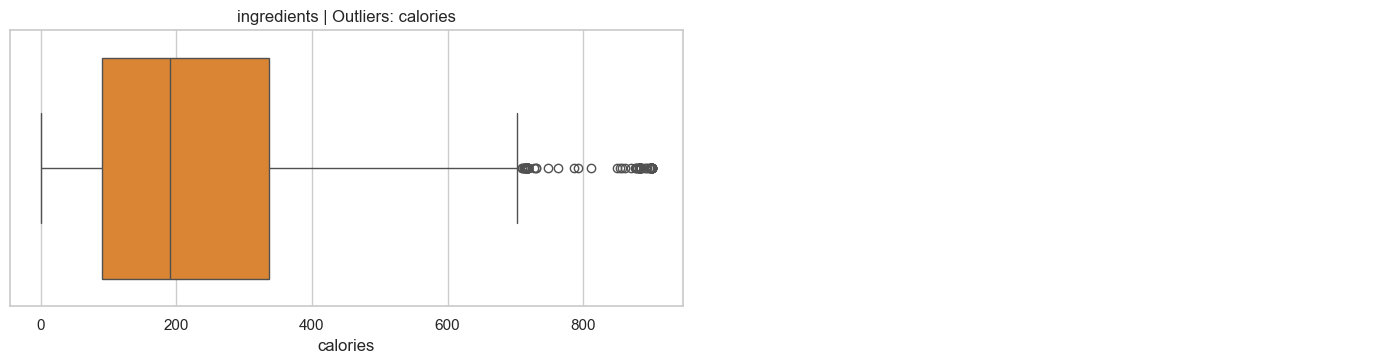

Outlier summary (IQR):


,feature,outlier_count,outlier_pct
0,calories,148,1.68


EDA: nutrition_1
Numeric columns used: 14


,count,mean,std,min,25%,50%,75%,max
sodium_mg,39383.0,1067.232571,28957.009538,0.0,16.0,143.0,481.0,4690000.0
cholesterol_mg,34158.0,62.575833,2141.337343,0.0,0.0,0.0,38.0,214000.0
vitamin_c_mg,22940.0,24.138259,1419.157682,0.0,0.0,0.0,5.2,210000.0
calcium_mg,34215.0,106.091172,1327.632746,0.0,5.0,29.0,98.0,150000.0


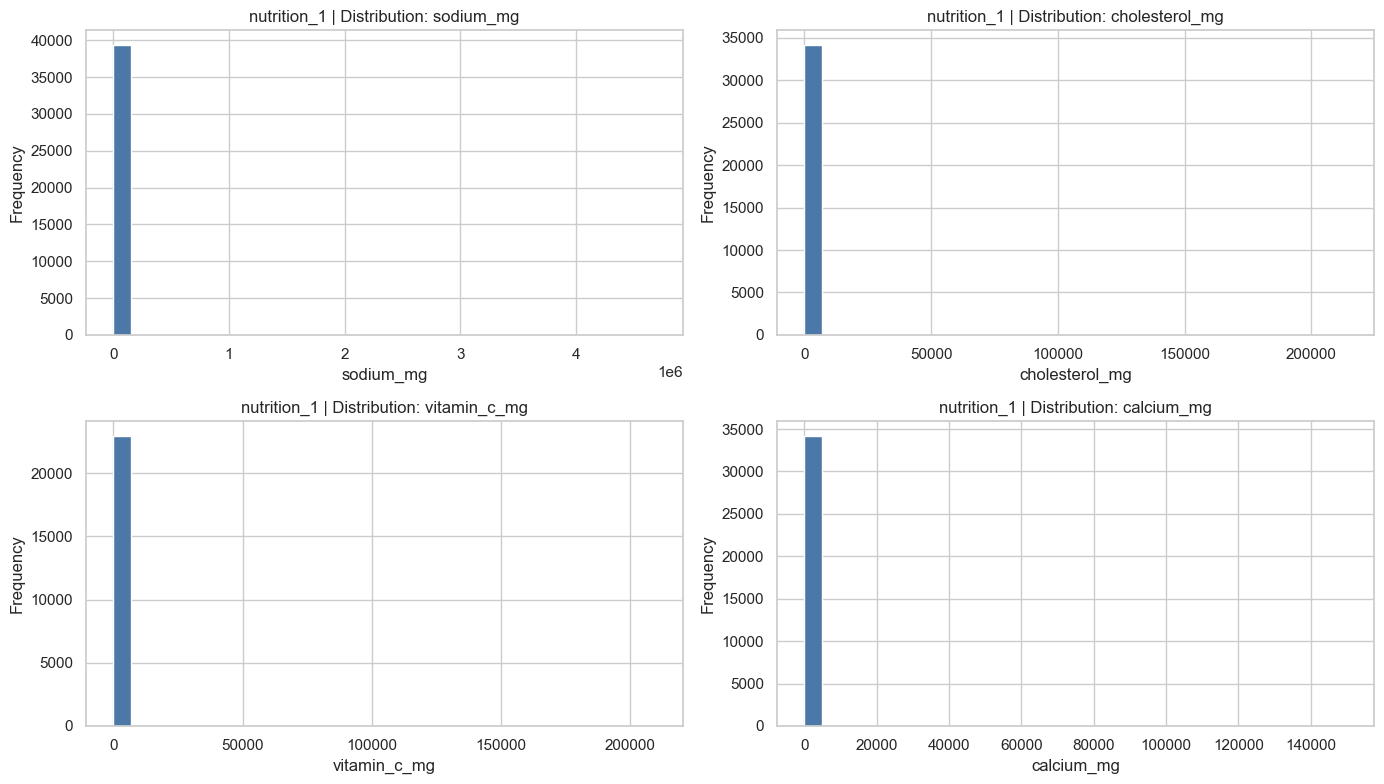

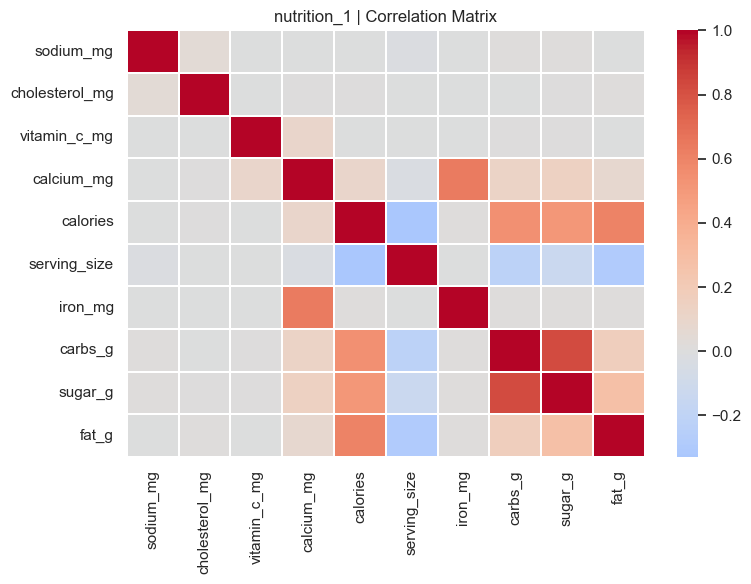

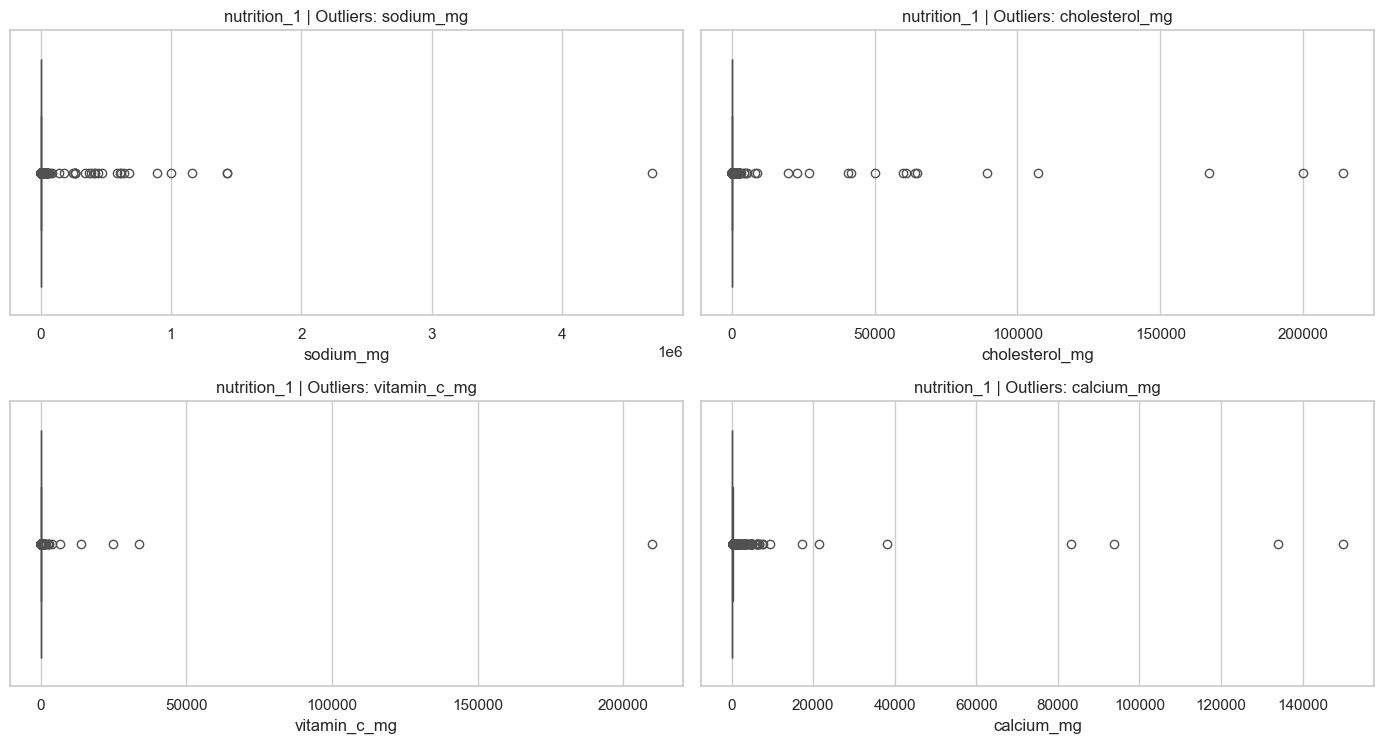

Outlier summary (IQR):


,feature,outlier_count,outlier_pct
7,vitamin_c_mg,3953,17.23
11,sugar_g,3575,10.00
8,fiber_g,2536,7.52
6,saturated_fat_g,2560,7.31
3,calcium_mg,2482,7.25
10,sodium_mg,2424,6.15
12,cholesterol_mg,1806,5.29
4,fat_g,2017,5.08
0,serving_size,1430,4.49
9,iron_mg,1475,4.31


EDA: nutrition_2
Numeric columns used: 3


,count,mean,std,min,25%,50%,75%,max
Carbs(g),7806.0,152.123189,185.907322,0.06,36.1625,93.415,205.9150,3405.55
Fat(g),7806.0,117.328542,122.098117,0.00,41.0675,84.865,158.2900,1930.24
Protein(g),7806.0,83.231498,89.797282,0.00,24.4150,56.280,112.3575,1273.61


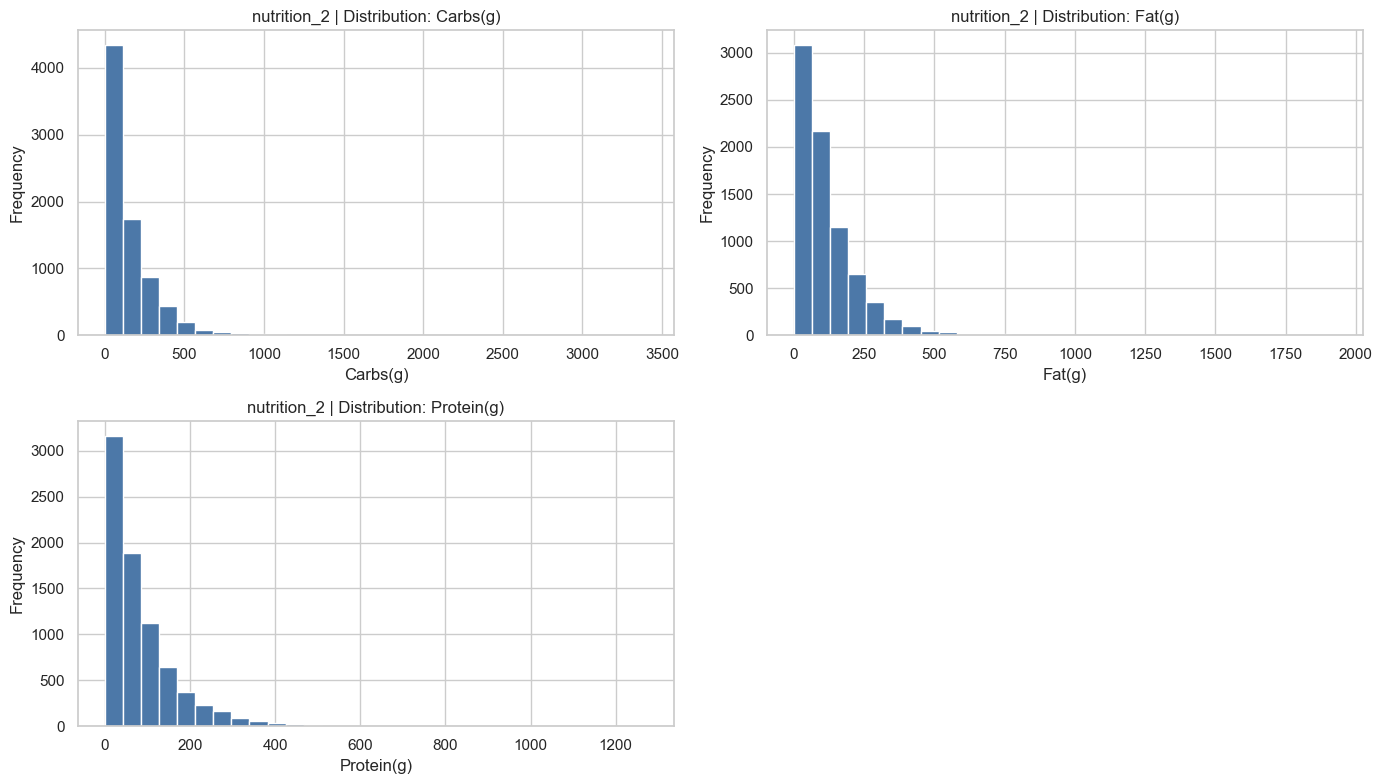

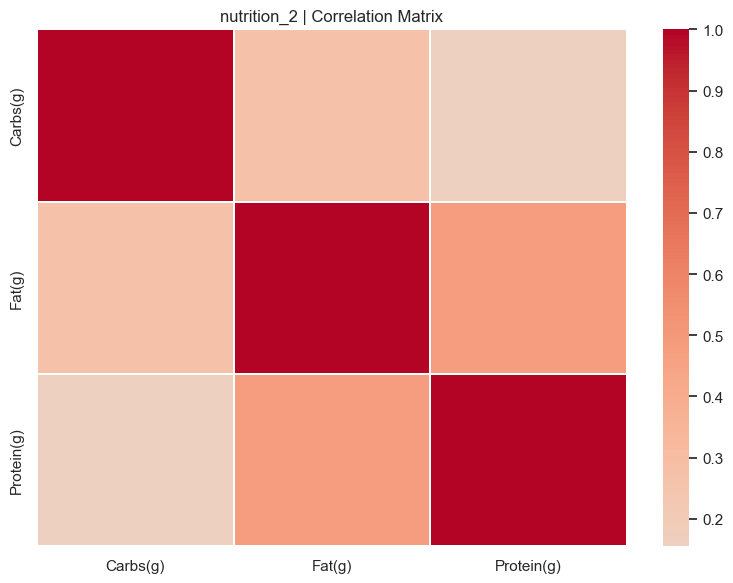

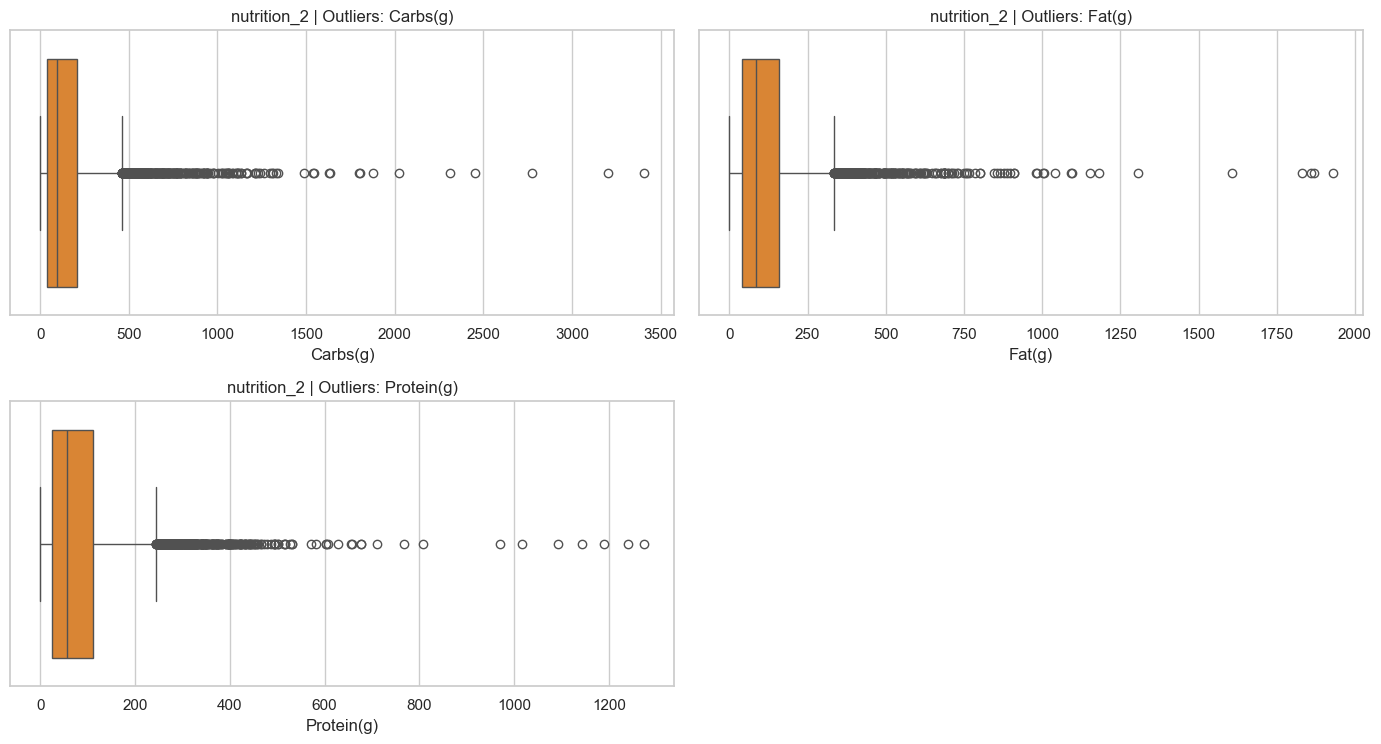

Outlier summary (IQR):


,feature,outlier_count,outlier_pct
0,Protein(g),440,5.64
1,Carbs(g),410,5.25
2,Fat(g),359,4.60


EDA: diet_recommendations
Numeric columns used: 19


,count,mean,std,min,25%,50%,75%,max
Daily_Steps,5000.0,8458.9228,3742.408853,2004.0,5278.75,8452.0,11671.75,14997.0
Recommended_Calories,5000.0,2046.2360,671.380142,725.0,1478.00,2044.0,2621.00,3372.0
Caloric_Intake,5000.0,2347.3502,659.880146,1200.0,1777.00,2350.5,2921.25,3499.0
Recommended_Carbs,5000.0,248.3286,91.152909,50.0,173.00,246.0,324.00,447.0


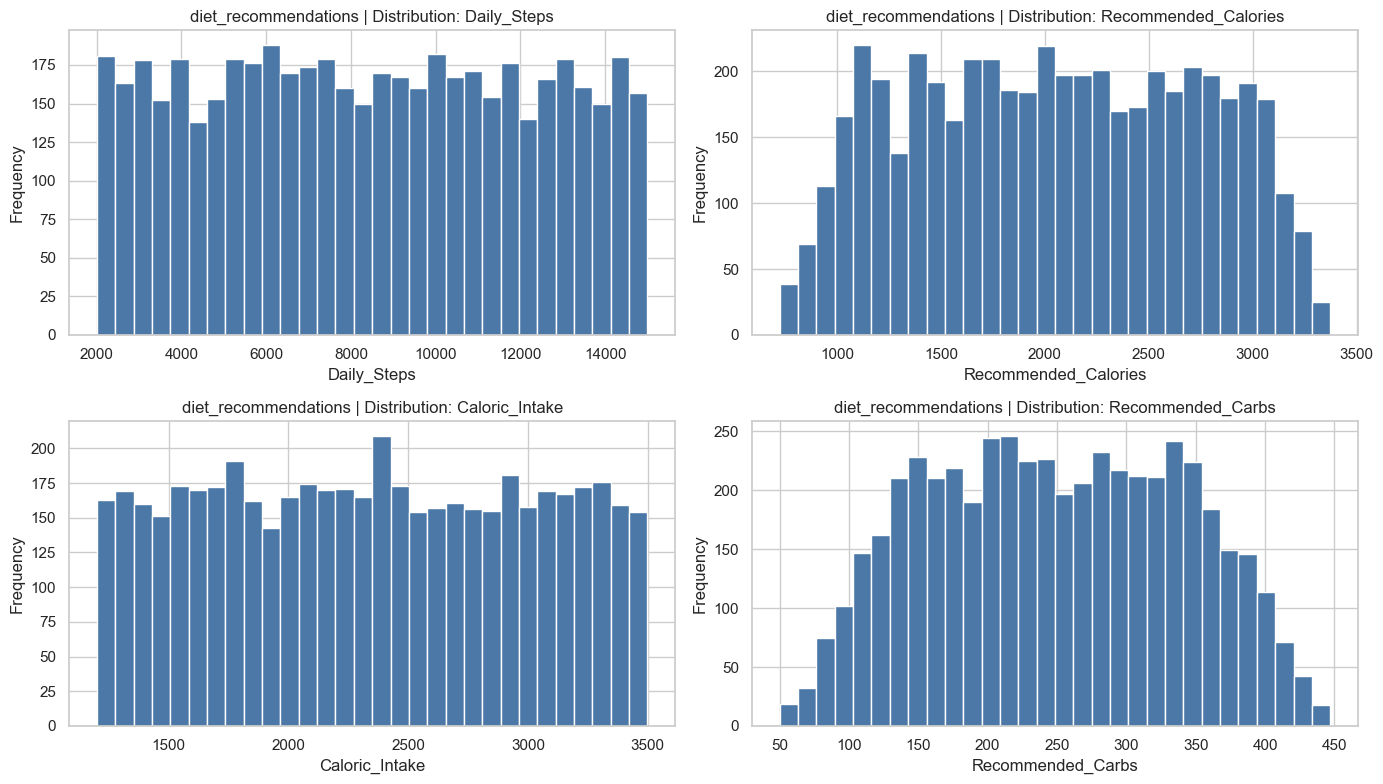

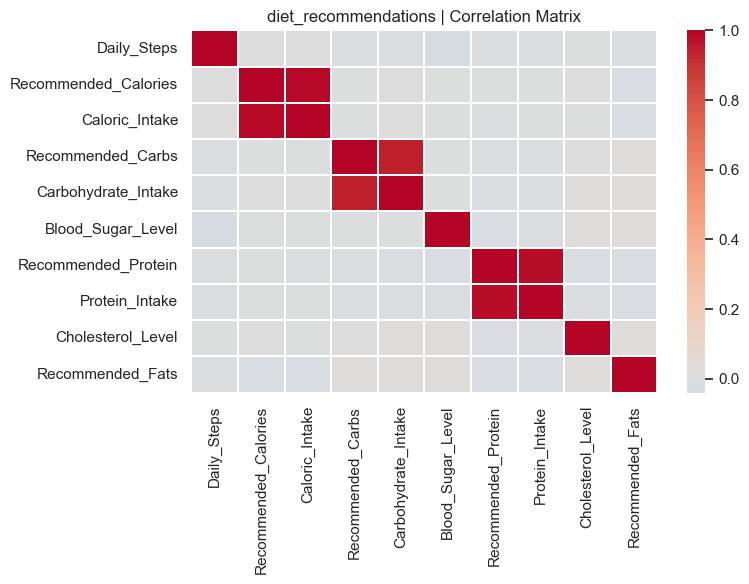

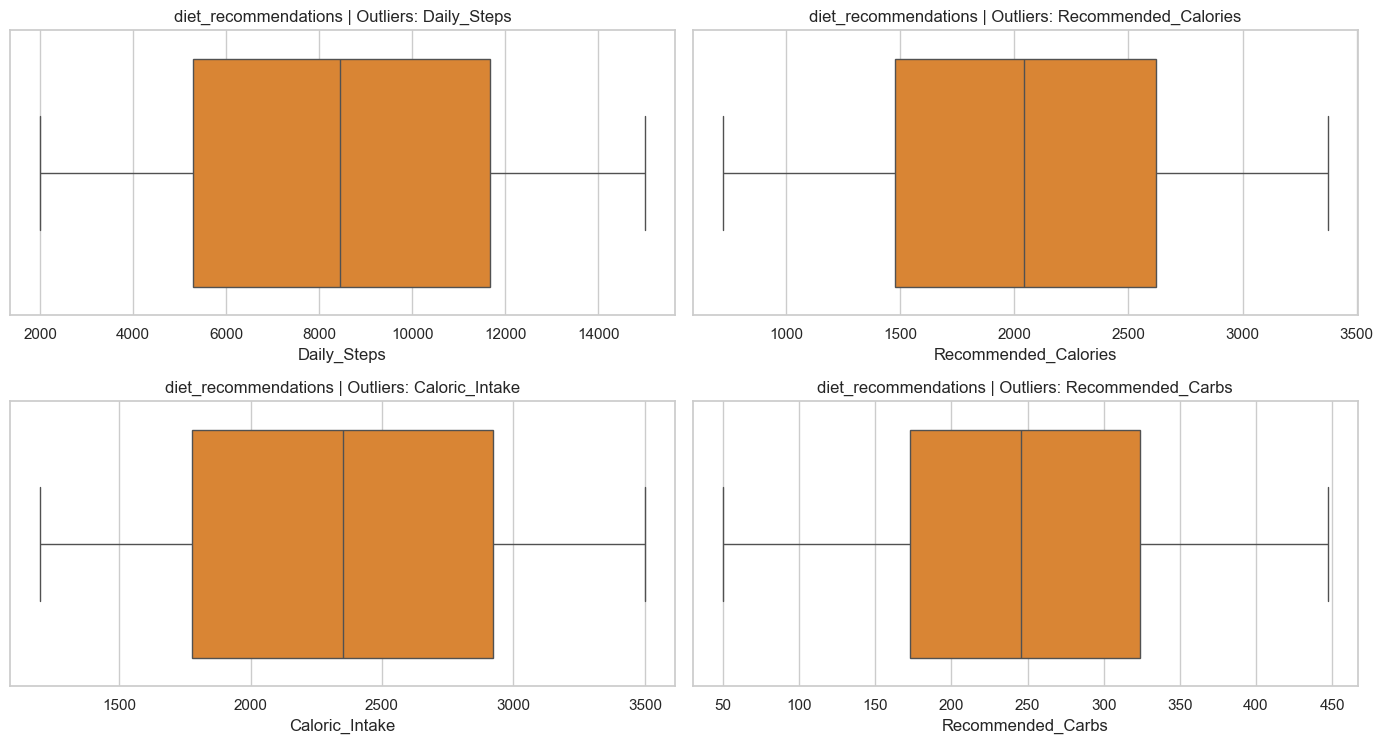

Outlier summary (IQR):


,feature,outlier_count,outlier_pct
3,BMI,4,0.08
0,Age,0,0.00
10,Sleep_Hours,0,0.00
17,Recommended_Carbs,0,0.00
16,Recommended_Protein,0,0.00
15,Recommended_Calories,0,0.00
14,Fat_Intake,0,0.00
13,Carbohydrate_Intake,0,0.00
12,Protein_Intake,0,0.00
11,Caloric_Intake,0,0.00


In [8]:
# 3.1) Distribution + Correlation + Outlier (simple and clear)
from math import ceil

MAX_PLOTS_PER_DATASET = 4
BINS = 30

for dataset_name, df in DATASETS.items():
    print("=" * 90)
    print(f"EDA: {dataset_name}")

    num_df = df.select_dtypes(include=np.number).copy()

    # Remove index/id-like columns and constant columns for cleaner EDA.
    keep_cols = []
    for col in num_df.columns:
        col_lower = str(col).lower()
        is_id_like = col_lower.startswith("unnamed") or col_lower == "id" or col_lower.endswith("_id")
        is_constant = num_df[col].nunique(dropna=True) <= 1
        if not is_id_like and not is_constant:
            keep_cols.append(col)

    num_df = num_df[keep_cols]

    if num_df.empty:
        print("No numeric columns for EDA in this dataset.")
        continue

    # Use top columns by variation so plots are informative but not overwhelming.
    ordered_cols = num_df.std(numeric_only=True).sort_values(ascending=False).index.tolist()
    plot_cols = ordered_cols[:MAX_PLOTS_PER_DATASET]

    print(f"Numeric columns used: {num_df.shape[1]}")
    display(num_df[plot_cols].describe().T)

    # 1) Distribution
    nrows = ceil(len(plot_cols) / 2)
    fig, axes = plt.subplots(nrows, 2, figsize=(14, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(plot_cols):
        axes[i].hist(num_df[col].dropna(), bins=BINS, color="#4C78A8", edgecolor="white")
        axes[i].set_title(f"{dataset_name} | Distribution: {col}")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Frequency")

    for i in range(len(plot_cols), len(axes)):
        axes[i].axis("off")

    fig.tight_layout()
    plt.show()

    # 2) Correlation
    if num_df.shape[1] >= 2:
        corr_cols = ordered_cols[: min(10, len(ordered_cols))]
        corr = num_df[corr_cols].corr(numeric_only=True)

        plt.figure(figsize=(8, 6))
        if sns is not None:
            sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.3)
        else:
            plt.imshow(corr, cmap="coolwarm", aspect="auto")
            plt.colorbar(label="Correlation")
            plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
            plt.yticks(range(len(corr.index)), corr.index)
        plt.title(f"{dataset_name} | Correlation Matrix")
        plt.tight_layout()
        plt.show()

    # 3) Outlier
    nrows = ceil(len(plot_cols) / 2)
    fig, axes = plt.subplots(nrows, 2, figsize=(14, 3.8 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(plot_cols):
        s = num_df[col].dropna()
        if sns is not None:
            sns.boxplot(x=s, ax=axes[i], color="#F58518")
        else:
            axes[i].boxplot(s, vert=False)
        axes[i].set_title(f"{dataset_name} | Outliers: {col}")
        axes[i].set_xlabel(col)

    for i in range(len(plot_cols), len(axes)):
        axes[i].axis("off")

    fig.tight_layout()
    plt.show()

    # IQR summary (quick table)
    outlier_rows = []
    for col in num_df.columns:
        s = num_df[col].dropna()
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outlier_count = int(((s < lower) | (s > upper)).sum())
        outlier_rows.append(
            {
                "feature": col,
                "outlier_count": outlier_count,
                "outlier_pct": round(outlier_count / len(s) * 100, 2),
            }
        )

    outlier_summary = pd.DataFrame(outlier_rows).sort_values("outlier_pct", ascending=False)
    print("Outlier summary (IQR):")
    display(outlier_summary.head(10))

**ฝากทำส่วนนี้ต่อด้วยนะครับอิตาโดริคุง by yossayut**
1. Top Ingredients 
2.  Nutrition Distribution 
3. High Calorie Food Analysis 
4. Ingredient Complexity 
5. Nutrition Correlation

,rank,ingredient,count
0,1,cornstarch,1
1,2,"nuts, pecans",1
2,3,"eggplant, raw",1
3,4,"teff, uncooked",1
4,5,"sherbet, orange",1
5,6,"cauliflower, raw",1
6,7,"taro leaves, raw",1
7,8,"lamb, raw, ground",1
8,9,"cheese, camembert",1
9,10,vegetarian fillets,1


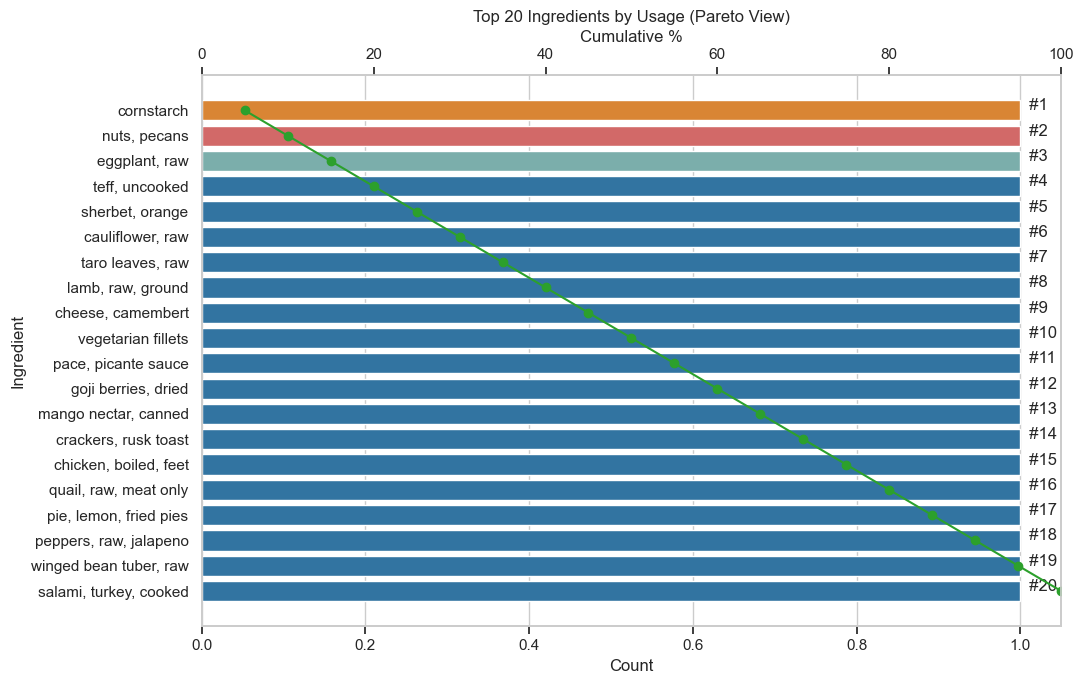

In [9]:
# 4) Top Ingredients
ingredient_df = ingredients.copy()

# Try to detect likely ingredient name and recipe id columns.
ingredient_name_candidates = [
    "ingredient_name",
    "ingredient",
    "name",
    "ingredient_name_en",
    "ing_name",
    "ingredient_name_th",
    "ingredient_name_thai",
    "ingredient_name_eng",
]
recipe_id_candidates = ["recipe_id", "recipeid", "recipeId", "id", "recipe_id"]

def pick_first_existing(columns, candidates):
    for c in candidates:
        if c in columns:
            return c
    return None

name_col = pick_first_existing(ingredient_df.columns, ingredient_name_candidates)
recipe_id_col = pick_first_existing(ingredient_df.columns, recipe_id_candidates)

if name_col is None:
    print("No ingredient name column found. Available columns:")
    display(ingredient_df.columns.to_frame(index=False))
else:
    # Clean ingredient names and count usage.
    ingredient_series = (
        ingredient_df[name_col]
        .astype(str)
        .str.strip()
        .str.lower()
        .replace({"": np.nan, "nan": np.nan})
        .dropna()
    )
    ingredient_counts = (
        ingredient_series
        .value_counts()
        .rename_axis("ingredient")
        .reset_index(name="count")
    )

    top_n = 20
    top_ingredients = ingredient_counts.head(top_n).copy()
    top_ingredients.insert(0, "rank", range(1, len(top_ingredients) + 1))
    display(top_ingredients)

    # Optional: show how many unique recipes are linked for each top ingredient.
    if recipe_id_col is not None:
        recipe_counts = (
            ingredient_df[[recipe_id_col, name_col]]
            .dropna()
            .assign(**{name_col: lambda d: d[name_col].astype(str).str.strip().str.lower()})
            .groupby(name_col)[recipe_id_col]
            .nunique()
            .rename("unique_recipes")
        )
        top_ingredients = top_ingredients.merge(
            recipe_counts, left_on="ingredient", right_index=True, how="left"
        )
        display(top_ingredients)

    # Pareto-style chart: bars + cumulative percentage line
    top_ingredients = top_ingredients.copy()
    top_ingredients["cum_pct"] = top_ingredients["count"].cumsum() / top_ingredients["count"].sum() * 100

    fig, ax = plt.subplots(figsize=(11, 7))
    palette = ["#1f77b4"] * len(top_ingredients)
    for i in range(min(3, len(top_ingredients))):
        palette[i] = ["#f58518", "#e45756", "#72b7b2"][i]
    if sns is not None:
        sns.barplot(
            data=top_ingredients,
            x="count",
            y="ingredient",
            palette=palette,
            ax=ax,
        )
    else:
        ax.barh(top_ingredients["ingredient"], top_ingredients["count"], color=palette)
        ax.invert_yaxis()
    ax.set_title(f"Top {top_n} Ingredients by Usage (Pareto View)")
    ax.set_xlabel("Count")
    ax.set_ylabel("Ingredient")
    for idx, row in top_ingredients.iterrows():
        ax.text(row["count"], idx, f"  #{int(row['rank'])}")

    ax2 = ax.twiny()
    ax2.plot(top_ingredients["cum_pct"], range(len(top_ingredients)), color="#2ca02c", marker="o")
    ax2.set_xlim(0, 100)
    ax2.set_xlabel("Cumulative %")
    ax2.grid(False)

    plt.tight_layout()
    plt.show()

## 2) Nutrition Distribution

ดูการกระจายของคอลัมน์สารอาหารที่เป็นตัวเลข เพื่อดู skew, outliers และช่วงค่าที่พบบ่อย

Nutrition Distribution: nutrition_1


,count,mean,std,min,25%,50%,75%,max
sodium_mg,39383.0,1067.232571,28957.009538,0.0,16.0,143.0,481.0,4690000.0
cholesterol_mg,34158.0,62.575833,2141.337343,0.0,0.0,0.0,38.0,214000.0
vitamin_c_mg,22940.0,24.138259,1419.157682,0.0,0.0,0.0,5.2,210000.0
calcium_mg,34215.0,106.091172,1327.632746,0.0,5.0,29.0,98.0,150000.0
calories,39538.0,308.159861,392.575965,0.0,85.0,250.0,404.0,37600.0
serving_size,31842.0,92.563962,100.581765,0.0,28.0,55.0,118.0,5055.0


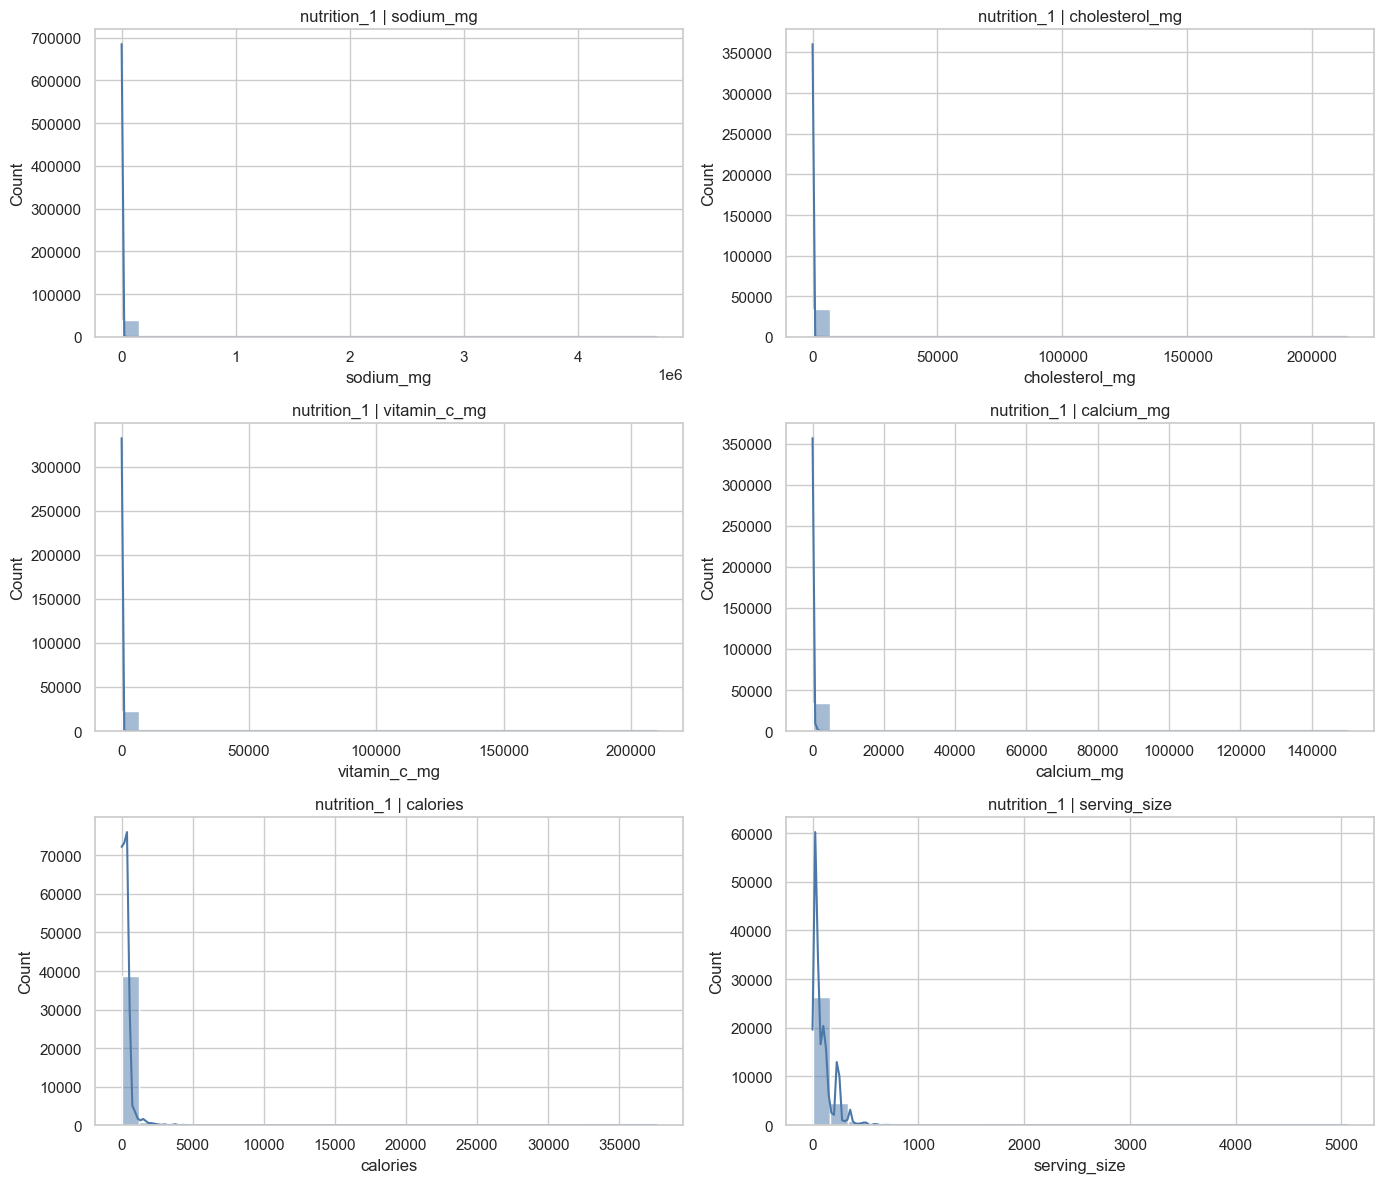

Nutrition Distribution: nutrition_2


,count,mean,std,min,25%,50%,75%,max
Carbs(g),7806.0,152.123189,185.907322,0.06,36.1625,93.415,205.9150,3405.55
Fat(g),7806.0,117.328542,122.098117,0.00,41.0675,84.865,158.2900,1930.24
Protein(g),7806.0,83.231498,89.797282,0.00,24.4150,56.280,112.3575,1273.61


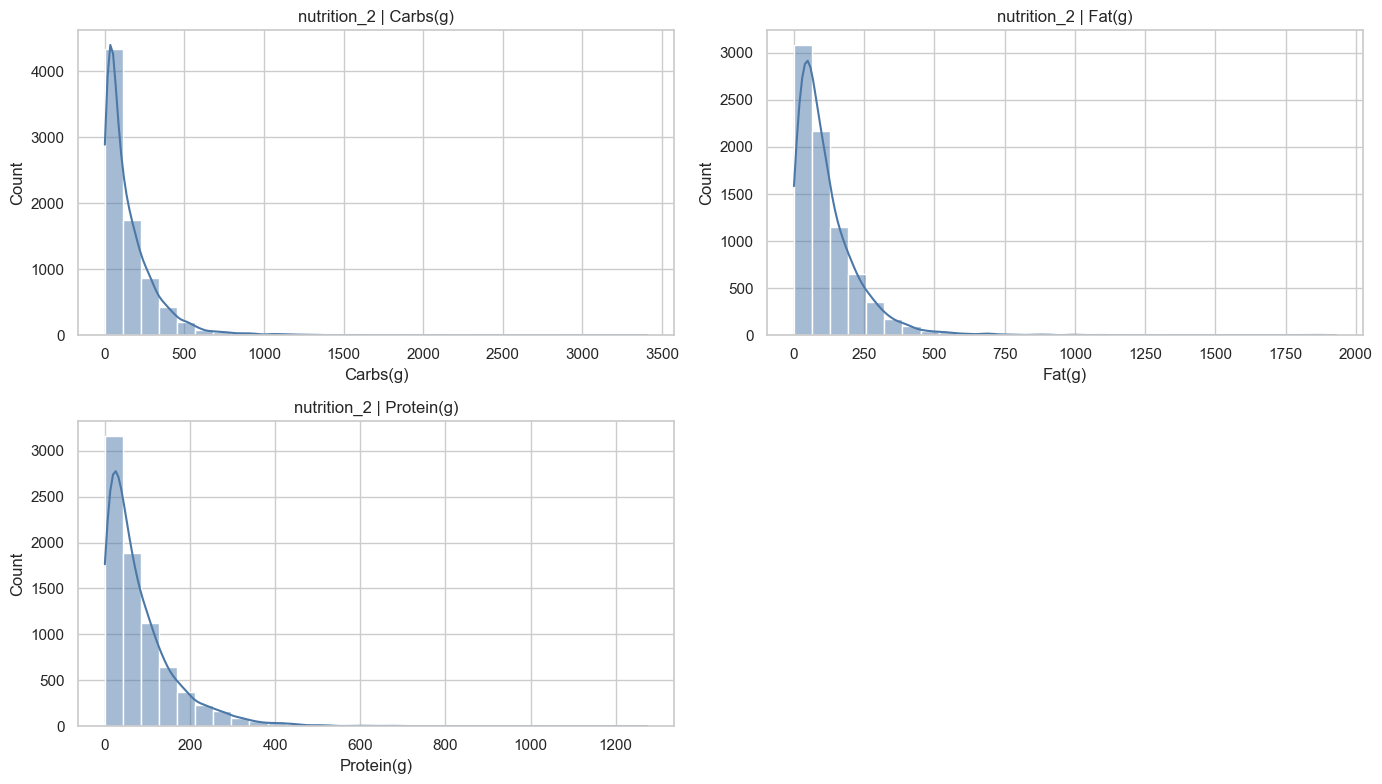

In [10]:
# 2) Nutrition Distribution
nutrition_datasets = {
    "nutrition_1": nutrition_1,
    "nutrition_2": nutrition_2,
}

def pick_first_existing(columns, candidates):
    for c in candidates:
        if c in columns:
            return c
    return None

MAX_NUTRITION_COLS = 6
BINS = 30

for name, df in nutrition_datasets.items():
    print("=" * 90)
    print(f"Nutrition Distribution: {name}")

    num_df = df.select_dtypes(include=np.number).copy()
    if num_df.empty:
        print("No numeric columns found.")
        continue

    keep_cols = []
    for col in num_df.columns:
        col_lower = str(col).lower()
        is_id_like = col_lower.startswith("unnamed") or col_lower == "id" or col_lower.endswith("_id")
        is_constant = num_df[col].nunique(dropna=True) <= 1
        if not is_id_like and not is_constant:
            keep_cols.append(col)

    num_df = num_df[keep_cols]
    if num_df.empty:
        print("No useful numeric columns for distribution.")
        continue

    ordered_cols = num_df.std(numeric_only=True).sort_values(ascending=False).index.tolist()
    plot_cols = ordered_cols[:MAX_NUTRITION_COLS]
    display(num_df[plot_cols].describe().T)

    nrows = int(np.ceil(len(plot_cols) / 2))
    fig, axes = plt.subplots(nrows, 2, figsize=(14, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(plot_cols):
        if sns is not None:
            sns.histplot(num_df[col].dropna(), bins=BINS, kde=True, ax=axes[i], color="#4C78A8")
        else:
            axes[i].hist(num_df[col].dropna(), bins=BINS, color="#4C78A8", edgecolor="white")
        axes[i].set_title(f"{name} | {col}")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Count")

    for i in range(len(plot_cols), len(axes)):
        axes[i].axis("off")

    fig.tight_layout()
    plt.show()

## 3) High Calorie Food Analysis

ดูเมนู/อาหารที่มีแคลอรีสูงสุด และเปรียบเทียบ Top N

In [11]:
# 3) High Calorie Food Analysis
cal_df = calories.copy()

def pick_first_existing(columns, candidates):
    for c in candidates:
        if c in columns:
            return c
    return None

def find_col_by_keywords(columns, keywords):
    for c in columns:
        col_lower = str(c).lower()
        if any(k in col_lower for k in keywords):
            return c
    return None

calorie_col = pick_first_existing(
    cal_df.columns,
    ["calories", "calorie", "kcal", "energy", "energy_kcal", "total_calories"],
)
if calorie_col is None:
    calorie_col = find_col_by_keywords(cal_df.columns, ["calorie", "kcal", "energy"])

name_col = pick_first_existing(cal_df.columns, ["name", "recipe_name", "title", "food_name", "item"])
recipe_id_col = pick_first_existing(cal_df.columns, ["recipe_id", "recipeid", "recipeId", "id"])

if calorie_col is None:
    print("No calorie column found. Available columns:")
    display(cal_df.columns.to_frame(index=False))
else:
    cal_df = cal_df.copy()
    cal_df["calories_value"] = pd.to_numeric(cal_df[calorie_col], errors="coerce")
    cal_df = cal_df.dropna(subset=["calories_value"])

    if name_col is None and recipe_id_col is not None:
        recipe_name_col = pick_first_existing(recipes.columns, ["name", "recipe_name", "title"])
        if recipe_name_col is not None and recipe_id_col in recipes.columns:
            cal_df = cal_df.merge(
                recipes[[recipe_id_col, recipe_name_col]],
                on=recipe_id_col,
                how="left",
            )
            name_col = recipe_name_col

    if name_col is None:
        cal_df["label"] = cal_df.index.astype(str)
        label_col = "label"
    else:
        label_col = name_col

    top_n = 20
    top_calories = cal_df.sort_values("calories_value", ascending=False).head(top_n)
    display(top_calories[[label_col, "calories_value"]])

    plt.figure(figsize=(11, 7))
    if sns is not None:
        sns.barplot(
            data=top_calories,
            x="calories_value",
            y=label_col,
            color="#E45756",
        )
    else:
        plt.barh(top_calories[label_col], top_calories["calories_value"], color="#E45756")
        plt.gca().invert_yaxis()
    plt.title(f"Top {top_n} High-Calorie Foods")
    plt.xlabel("Calories")
    plt.ylabel("Food / Recipe")
    plt.tight_layout()
    plt.show()

No calorie column found. Available columns:


,0
0,FoodCategory
1,FoodItem
2,per100grams
3,Cals_per100grams
4,KJ_per100grams


## 4) Ingredient Complexity

วัดความซับซ้อนของเมนูจากจำนวนวัตถุดิบต่อหนึ่งเมนู

In [12]:
# 4) Ingredient Complexity
ingredient_df = ingredients.copy()

def pick_first_existing(columns, candidates):
    for c in candidates:
        if c in columns:
            return c
    return None

recipe_id_col = pick_first_existing(ingredient_df.columns, ["recipe_id", "recipeid", "recipeId", "id"])
name_col = pick_first_existing(ingredient_df.columns, ["ingredient_name", "ingredient", "name"])

if recipe_id_col is None:
    print("No recipe id column found. Available columns:")
    display(ingredient_df.columns.to_frame(index=False))
else:
    if name_col is None:
        complexity = ingredient_df.groupby(recipe_id_col).size().rename("ingredient_count").reset_index()
    else:
        complexity = (
            ingredient_df[[recipe_id_col, name_col]]
            .dropna()
            .assign(**{name_col: lambda d: d[name_col].astype(str).str.strip().str.lower()})
            .groupby(recipe_id_col)[name_col]
            .nunique()
            .rename("ingredient_count")
            .reset_index()
        )

    display(complexity["ingredient_count"].describe())

    plt.figure(figsize=(10, 6))
    if sns is not None:
        sns.histplot(complexity["ingredient_count"], bins=30, kde=True, color="#4C78A8")
    else:
        plt.hist(complexity["ingredient_count"], bins=30, color="#4C78A8", edgecolor="white")
    plt.title("Ingredient Complexity Distribution")
    plt.xlabel("Number of Ingredients per Recipe")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    top_n = 15
    top_complex = complexity.sort_values("ingredient_count", ascending=False).head(top_n)

    recipe_name_col = pick_first_existing(recipes.columns, ["name", "recipe_name", "title"])
    if recipe_name_col is not None and recipe_id_col in recipes.columns:
        top_complex = top_complex.merge(
            recipes[[recipe_id_col, recipe_name_col]], on=recipe_id_col, how="left"
        )
        display(top_complex[[recipe_id_col, recipe_name_col, "ingredient_count"]])
    else:
        display(top_complex[[recipe_id_col, "ingredient_count"]])

    plt.figure(figsize=(10, 7))
    if sns is not None:
        sns.barplot(
            data=top_complex,
            x="ingredient_count",
            y=recipe_id_col,
            color="#72B7B2",
        )
    else:
        plt.barh(top_complex[recipe_id_col].astype(str), top_complex["ingredient_count"], color="#72B7B2")
        plt.gca().invert_yaxis()
    plt.title(f"Top {top_n} Most Complex Recipes")
    plt.xlabel("Ingredient Count")
    plt.ylabel("Recipe")
    plt.tight_layout()
    plt.show()

No recipe id column found. Available columns:


,0
0,Unnamed: 0
1,name
2,serving_size
3,calories
4,total_fat
...,...
72,alcohol
73,ash
74,caffeine
75,theobromine


## 5) Nutrition Correlation

ดูความสัมพันธ์ระหว่างสารอาหารหลักด้วย heatmap

Nutrition Correlation: nutrition_1


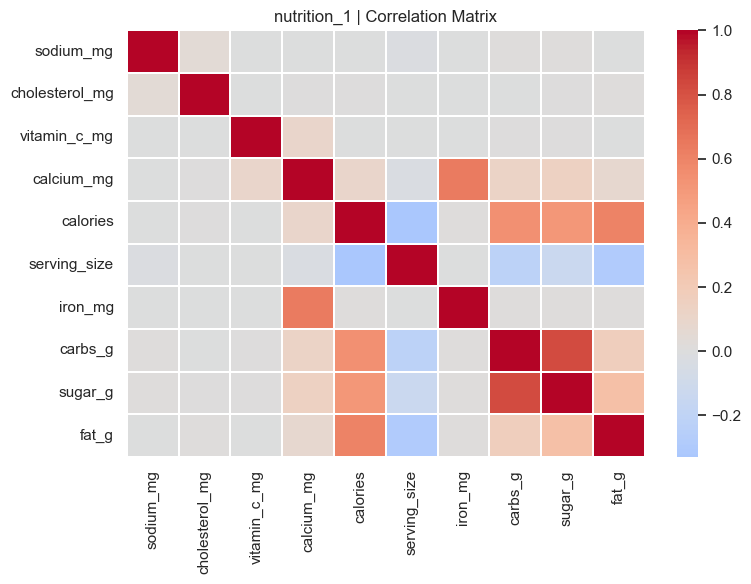

Nutrition Correlation: nutrition_2


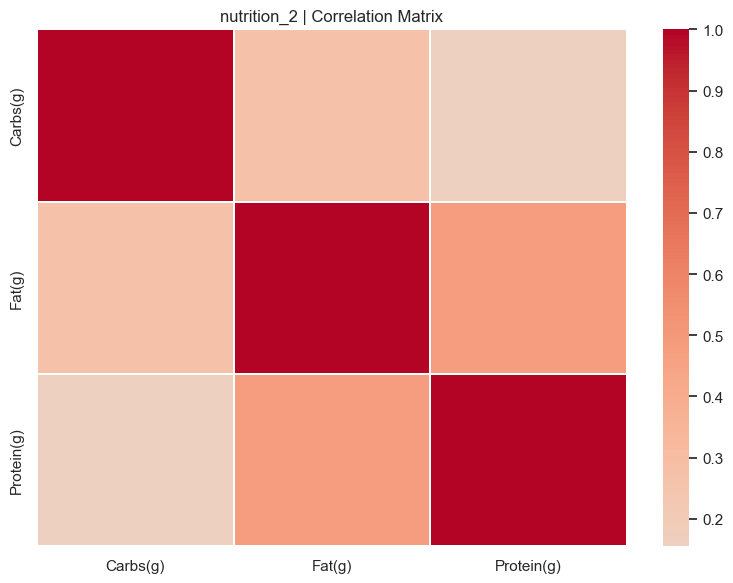

In [13]:
# 5) Nutrition Correlation
nutrition_datasets = {
    "nutrition_1": nutrition_1,
    "nutrition_2": nutrition_2,
}

for name, df in nutrition_datasets.items():
    print("=" * 90)
    print(f"Nutrition Correlation: {name}")

    num_df = df.select_dtypes(include=np.number).copy()
    if num_df.empty:
        print("No numeric columns found.")
        continue

    keep_cols = []
    for col in num_df.columns:
        col_lower = str(col).lower()
        is_id_like = col_lower.startswith("unnamed") or col_lower == "id" or col_lower.endswith("_id")
        is_constant = num_df[col].nunique(dropna=True) <= 1
        if not is_id_like and not is_constant:
            keep_cols.append(col)

    num_df = num_df[keep_cols]
    if num_df.shape[1] < 2:
        print("Not enough numeric columns for correlation.")
        continue

    corr_cols = num_df.std(numeric_only=True).sort_values(ascending=False).head(10).index.tolist()
    corr = num_df[corr_cols].corr(numeric_only=True)

    plt.figure(figsize=(8, 6))
    if sns is not None:
        sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.3, annot=False)
    else:
        plt.imshow(corr, cmap="coolwarm", aspect="auto")
        plt.colorbar(label="Correlation")
        plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
        plt.yticks(range(len(corr.index)), corr.index)
    plt.title(f"{name} | Correlation Matrix")
    plt.tight_layout()
    plt.show()